# Notebook 8: Movie Chatbot with Search + Curated Knowledge + URL Fetch

## Features:
- ✅ Web search for current information
- ✅ Curated knowledge base from URLs in Excel file
- ✅ **NEW: Dynamic URL fetching** - Fetch any URL on-demand
- ✅ Conversational memory
- ✅ Three-tool agentic system

## What's New in This Update:
- **fetch_url_content** tool - Can now fetch any specific URL you provide!
- Perfect for ad-hoc queries about specific movie pages
- Works with IMDB, TMDB, or any movie database URL

## Tools Available:
1. **search_web** - General web search (SERPER API)
2. **curated_knowledge_search** - Search pre-loaded URLs from Excel
3. **fetch_url_content** - Fetch any specific URL on-demand (NEW!)

## Installation

In [2]:
%pip install langchain langchain-community langgraph python-dotenv openpyxl pandas langchain-openai google-search-results faiss-cpu --quiet

print("✓ Packages installed")

Note: you may need to restart the kernel to use updated packages.
✓ Packages installed


## Imports

In [1]:
import os, json
import pandas as pd
import requests
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.tools import tool
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

from ai_course_utils import load_llm_from_env, load_use_case_config, display_config
from IPython.display import Image, display


# Load environment
load_dotenv()

print("✓ Imports successful")

✓ Imports successful


In [2]:
TMDB_API_KEY = os.getenv("TMDB_API_KEY")  # or hardcode for testing

In [3]:
# Load TMDB Data 

def load_tmdb_data(movie_id):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}"

    params = {"api_key": TMDB_API_KEY}

    response = requests.get(url, params=params)

    return response.json()



In [4]:
movie_id = 862
movie_json = load_tmdb_data(movie_id)
print(json.dumps(movie_json, indent = 2))
poster_path = movie_json['poster_path']
poster_url = f"https://image.tmdb.org/t/p/w500{poster_path}"
display(Image(url=poster_url))

{
  "adult": false,
  "backdrop_path": "/bSoOThXLrbgtphS2eZjwy2xYwVt.jpg",
  "belongs_to_collection": {
    "id": 10194,
    "name": "Toy Story Collection",
    "poster_path": "/7G9915LfUQ2lVfwMEEhDsn3kT4B.jpg",
    "backdrop_path": "/hApclyB9NEZEQujAVajzi5iWE4a.jpg"
  },
  "budget": 30000000,
  "genres": [
    {
      "id": 10751,
      "name": "Family"
    },
    {
      "id": 35,
      "name": "Comedy"
    },
    {
      "id": 16,
      "name": "Animation"
    },
    {
      "id": 12,
      "name": "Adventure"
    }
  ],
  "homepage": "http://toystory.disney.com/toy-story",
  "id": 862,
  "imdb_id": "tt0114709",
  "origin_country": [
    "US"
  ],
  "original_language": "en",
  "original_title": "Toy Story",
  "overview": "Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually

In [5]:
df_movie_abt = pd.read_csv("../data/outputs/analytics_base_table.csv")
df_movie_abt

,Unnamed: 0,movieId,title,movielens_genres,avg_rating,number_of_viewers,imdbId,tmdbId
0,0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.920930,215.0,114709,862.0
1,1,2,Jumanji (1995),Adventure|Children|Fantasy,3.431818,110.0,113497,8844.0
2,2,3,Grumpier Old Men (1995),Comedy|Romance,3.259615,52.0,113228,15602.0
3,3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,2.357143,7.0,114885,31357.0
4,4,5,Father of the Bride Part II (1995),Comedy,3.071429,49.0,113041,11862.0
...,...,...,...,...,...,...,...,...
9737,9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,4.000000,1.0,5476944,432131.0
9738,9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,3.500000,1.0,5914996,445030.0
9739,9739,193585,Flint (2017),Drama,3.500000,1.0,6397426,479308.0
9740,9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,3.500000,1.0,8391976,483455.0


In [ ]:
# Iterate and enrich
movie_abt_json = df_movie_abt.to_dict(orient="records")
#movie_abt_json

In [ ]:
#First 1000 records
for row in range(0, min(1000, len(movie_abt_json))):
    tmdb_id = movie_abt_json[row]["tmdbId"]
    
    if pd.notna(tmdb_id):
        movie_id = int(float(tmdb_id))
        tmdb_json = load_tmdb_data(movie_id)
        
        for key in tmdb_json.keys():
            movie_abt_json[row][key] = tmdb_json[key]

In [ ]:
#Second 1001 - 2000 record
for row in range(1000, min(2000, len(movie_abt_json))):
    tmdb_id = movie_abt_json[row]["tmdbId"]
    
    if pd.notna(tmdb_id):
        movie_id = int(float(tmdb_id))
        tmdb_json = load_tmdb_data(movie_id)
        
        for key in tmdb_json.keys():
            movie_abt_json[row][key] = tmdb_json[key]


ReadTimeout: HTTPSConnectionPool(host='api.themoviedb.org', port=443): Read timed out. (read timeout=None)

In [ ]:
# All records
for row in range(0, len(movie_abt_json)):
    tmdb_id = movie_abt_json[row]["tmdbId"]
    if pd.notna(tmdb_id):
        movie_id = int(float(tmdb_id))
        tmdb_json = load_tmdb_data(movie_id)
        for key in tmdb_json.keys():
            movie_abt_json[row][key]=tmdb_json[key]
movie_abt_json[0]

In [10]:
df_enhanced_movie_abt = pd.DataFrame(movie_abt_json)
df_enhanced_movie_abt.to_csv("../data/outputs/analytics_base_table_enrichedFirst1000.csv")

## Configuration

In [8]:
display_config()

API CONFIGURATION (.env file)
LLM Provider:    openai
LLM Model:       gpt-4.1-mini
Temperature:     0.0

API Keys Status:
  OpenAI               ✓ Set
  Google               ✗ Not set
  Mistral              ✗ Not set
  Anthropic            ✗ Not set
  Serper (Web Search)  ✓ Set

Data Files:
  Provide file paths as function parameters
  Example: load_use_case_config('your_file.xlsx')


## Load Use Case

In [9]:
# Load use case configuration
use_case_file = "../data/input/use_case_Movie_Recommendation.xlsx"
use_case_config = load_use_case_config(use_case_file)
system_prompt = use_case_config.get("agent_prompt", "You are a helpful movie assistant")

print(f"✓ System prompt loaded")

✓ Use case loaded: ../data/input/use_case_Movie_Recommendation.xlsx
  Components: user, agent_prompt, url
✓ System prompt loaded


In [14]:
# Load ABT Data file
ABT_File= "../data/outputs/analytics_base_table_with_genres_list.csv"

df = pd.read_csv(ABT_File)

print(df.head)


<bound method NDFrame.head of       Unnamed: 0  movieId                                      title  \
0              0        1                           Toy Story (1995)   
1              1        2                             Jumanji (1995)   
2              2        3                    Grumpier Old Men (1995)   
3              3        4                   Waiting to Exhale (1995)   
4              4        5         Father of the Bride Part II (1995)   
...          ...      ...                                        ...   
9737        9737   193581  Black Butler: Book of the Atlantic (2017)   
9738        9738   193583               No Game No Life: Zero (2017)   
9739        9739   193585                               Flint (2017)   
9740        9740   193587        Bungo Stray Dogs: Dead Apple (2018)   
9741        9741   193609        Andrew Dice Clay: Dice Rules (1991)   

                                           genres  avg rating   \
0     Adventure|Animation|Children|Come

## Extract URLs from Excel

In [26]:
# Extract URLs from use case file
url_string = use_case_config.get("url", "")

if url_string and url_string.strip():
    # Parse comma-separated URLs
    urls = [url.strip() for url in url_string.split(",") if url.strip()]
    print(f"✓ Found {len(urls)} URLs in use case file:")
    for i, url in enumerate(urls, 1):
        print(f"  {i}. {url}")
else:
    urls = []
    print("⚠️ No URLs found in use case file")

✓ Found 3 URLs in use case file:
  1. https://IMDB.com
  2. https://www.themoviedb.org
  3. https://grouplens.org/datasets/movielens/


## Build Curated Knowledge Base from Excel URLs

This creates a searchable knowledge base from the URLs in your Excel file.

In [27]:
url_retriever = None

if urls:
    try:
        print(f"\n📥 Loading content from {len(urls)} URLs...")
        
        # Load documents from URLs
        loader = WebBaseLoader(urls)
        documents = loader.load()
        print(f"  ✓ Loaded {len(documents)} documents")
        
        # Split into chunks
        text_splitter = RecursiveCharacterTextSplitter(
            chunk_size=1000,
            chunk_overlap=200
        )
        splits = text_splitter.split_documents(documents)
        print(f"  ✓ Created {len(splits)} text chunks")
        
        # Create vector store
        embeddings = OpenAIEmbeddings()
        vectorstore = FAISS.from_documents(splits, embeddings)
        print(f"  ✓ Vector store created")
        
        # Create retriever
        url_retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
        print(f"  ✓ Retriever ready")
        
        print("\n✅ Curated knowledge base built from Excel URLs!")
        
    except Exception as e:
        print(f"\n❌ Error building knowledge base: {str(e)}")
        print("Tools will still work, but curated_knowledge_search will be limited")
        url_retriever = None
else:
    print("\n⚠️ Skipping knowledge base (no URLs in Excel)")
    print("You can still use search_web and fetch_url_content")


📥 Loading content from 3 URLs...
  ✓ Loaded 3 documents
  ✓ Created 14 text chunks
  ✓ Vector store created
  ✓ Retriever ready

✅ Curated knowledge base built from Excel URLs!


## Define Tools

Three powerful tools for comprehensive movie information retrieval.

In [28]:
# Tool 1: General Web Search
@tool
def search_web(query: str) -> str:
    """
    Search the web for current movie information, news, and reviews.
    
    Best for:
    - Current information (box office, new releases)
    - General queries about movies
    - Recent news and reviews
    - When you need real-time data
    
    Args:
        query: Search query
        
    Returns:
        Search results from the web
    """
    try:
        search = GoogleSerperAPIWrapper()
        return search.run(query)
    except Exception as e:
        return f"Search error: {str(e)}"

print("✓ Tool 1: search_web defined")

✓ Tool 1: search_web defined


In [29]:
# Tool 2: Curated Knowledge Search (from Excel URLs)
@tool
def curated_knowledge_search(query: str) -> str:
    """
    Search the curated knowledge base built from URLs in the Excel file.
    
    Best for:
    - Information from pre-loaded trusted sources
    - Queries about content in the configured URLs
    - Domain-specific knowledge from IMDB, TMDB, etc.
    
    Args:
        query: Search query
        
    Returns:
        Relevant content from curated sources
    """
    if url_retriever is None:
        return "Curated knowledge base not available. No URLs were loaded from Excel file."
    
    try:
        docs = url_retriever.invoke(query)
        results = []
        for doc in docs:
            source = doc.metadata.get('source', 'Unknown')
            content = doc.page_content
            results.append(f"Source: {source}\nContent: {content}")
        
        return "\n\n---\n\n".join(results)
    except Exception as e:
        return f"Error searching curated knowledge: {str(e)}"

print("✓ Tool 2: curated_knowledge_search defined")

✓ Tool 2: curated_knowledge_search defined


In [30]:
# Tool 3: Dynamic URL Fetch 
@tool  
def fetch_url_content(url: str) -> str:
    """
    Fetch and extract content from any specific URL on-demand.
    
    Best for:
    - When user provides a specific URL (e.g., https://www.imdb.com/title/tt0113041)
    - Need fresh content from a specific webpage
    - Retrieving data from URLs not in the curated knowledge base
    - Ad-hoc queries about specific movie pages
    
    Args:
        url: Full URL to fetch (must include https:// or http://)
        
    Returns:
        Extracted text content from the URL
    
    Examples:
    - fetch_url_content("https://www.imdb.com/title/tt0113041")
    - fetch_url_content("https://www.themoviedb.org/movie/11862")
    """
    try:
        print(f"  🌐 Fetching: {url}")
        
        # Load the URL
        loader = WebBaseLoader([url])
        documents = loader.load()
        
        if documents:
            # Extract content (limit to 5000 chars to avoid token limits)
            content = documents[0].page_content[:5000]
            
            # Add metadata if available
            metadata = documents[0].metadata
            source_info = f"Source: {metadata.get('source', url)}"
            
            return f"{source_info}\n\nContent:\n{content}"
        else:
            return f"No content could be extracted from {url}"
            
    except Exception as e:
        return f"Error fetching {url}: {str(e)}\n\nPlease verify the URL is valid and accessible."

print("✓ Tool 3: fetch_url_content defined")

✓ Tool 3: fetch_url_content defined


In [31]:
# Configure tools based on availability
if url_retriever is not None:
    tools = [search_web, curated_knowledge_search, fetch_url_content]
    print(f"\n✅ All 3 tools configured:")
    print("  1. search_web - General web search")
    print("  2. curated_knowledge_search - Pre-loaded URLs from Excel")
    print("  3. fetch_url_content - Dynamic URL fetching")
else:
    tools = [search_web, fetch_url_content]
    print(f"\n✅ 2 tools configured:")
    print("  1. search_web - General web search")
    print("  2. fetch_url_content - Dynamic URL fetching")
    print("  (curated_knowledge_search not available - no URLs in Excel)")


✅ All 3 tools configured:
  1. search_web - General web search
  2. curated_knowledge_search - Pre-loaded URLs from Excel
  3. fetch_url_content - Dynamic URL fetching


## Initialize LLM

In [32]:
llm = load_llm_from_env()
model = llm.bind_tools(tools)

print("✓ LLM initialized with tools")

🤖 Loading LLM: openai / gpt-4.1-mini
✓ LLM initialized with tools


## Build Agent Graph with Memory

In [33]:
def call_model(state: MessagesState):
    """Agent node that decides which tools to use."""
    messages = [SystemMessage(content=system_prompt)] + state["messages"]
    return {"messages": [model.invoke(messages)]}

def should_continue(state: MessagesState):
    """Decision function: continue to tools or end."""
    last_message = state["messages"][-1]
    return "tools" if last_message.tool_calls else END

# Build workflow
workflow = StateGraph(MessagesState)
workflow.add_node("agent", call_model)
workflow.add_node("tools", ToolNode(tools))
workflow.set_entry_point("agent")
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {"tools": "tools", END: END}
)
workflow.add_edge("tools", "agent")

# Compile with memory
app = workflow.compile(checkpointer=MemorySaver())

print("✓ Agent graph with memory compiled")
app = workflow.compile()



✓ Agent graph with memory compiled


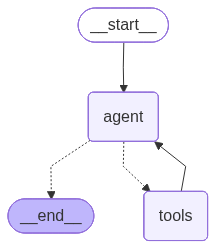

In [34]:
display(Image(app.get_graph().draw_mermaid_png()))

## Chat Helper Function

Use this to have conversations with the assistant.

In [35]:
def chat(user_input: str, thread_id: str = "default", verbose: bool = False) -> str:
    """
    Chat with the movie assistant.
    
    Args:
        user_input: Your message/query
        thread_id: Conversation thread ID (use same ID to continue conversation)
        verbose: Show which tools are being used
        
    Returns:
        Assistant's response
    """
    config = {"configurable": {"thread_id": thread_id}}
    
    if verbose:
        print(f"\n{'='*70}")
        print(f"Query: {user_input[:100]}...")
        print(f"{'='*70}")
        tools_used = []
    
    result = None
    for event in app.stream(
        {"messages": [HumanMessage(content=user_input)]},
        config,
        stream_mode="values"
    ):
        result = event
        if verbose:
            last_message = event["messages"][-1]
            if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
                for tool_call in last_message.tool_calls:
                    tool_name = tool_call['name']
                    if tool_name not in tools_used:
                        tools_used.append(tool_name)
                        print(f"  🔧 Using: {tool_name}")
    
    if verbose and tools_used:
        print(f"  ✓ Tools used: {', '.join(tools_used)}")
    
    return result["messages"][-1].content

print("\n🎬 Movie Chatbot Ready!")
print("\nUsage:")
print("  response = chat('Your question')")
print("  response = chat('Follow-up', thread_id='same_thread')")
print("  response = chat('Your question', verbose=True)  # See tool usage")


🎬 Movie Chatbot Ready!

Usage:
  response = chat('Your question')
  response = chat('Follow-up', thread_id='same_thread')
  response = chat('Your question', verbose=True)  # See tool usage


## Test 1: Dynamic URL Fetch (Specific IMDB URL)

Test the new fetch_url_content tool with a specific movie page.

In [36]:
# Test fetching specific IMDB URL
thread = "test1"

query1 = """Retrieve the following data from the URL https://www.imdb.com/title/tt0113041:
- Title
- Release year
- Genres
- IMDb rating
- Cast & crew
- Awards (if available)"""

print("User:", query1)
print("\n" + "-"*70 + "\n")

response1 = chat(query1, thread_id=thread, verbose=True)
print(f"\nBot: {response1}")

User: Retrieve the following data from the URL https://www.imdb.com/title/tt0113041:
- Title
- Release year
- Genres
- IMDb rating
- Cast & crew
- Awards (if available)

----------------------------------------------------------------------


Query: Retrieve the following data from the URL https://www.imdb.com/title/tt0113041:
- Title
- Release yea...
  🔧 Using: fetch_url_content
  🌐 Fetching: https://www.imdb.com/title/tt0113041
  ✓ Tools used: fetch_url_content

Bot: It seems that the content from the IMDb page for the movie with the ID tt0113041 could not be retrieved due to JavaScript being disabled or a verification requirement on the page. Would you like me to try searching for the movie details using another method? Also, could you please confirm the movie title or provide any other details you know about it?


## Test 2: Dynamic URL Fetch (Specific TMDB URL)

Test with a different movie database.

In [37]:
# Test fetching specific TMDB URL
thread = "test2"

query2 = """Retrieve the following data from the URL https://www.themoviedb.org/movie/11862:
- Genres
- Cast & crew
- Keywords
- Popularity scores
- Overview"""

print("\nUser:", query2)
print("\n" + "-"*70 + "\n")

response2 = chat(query2, thread_id=thread, verbose=True)
print(f"\nBot: {response2}")


User: Retrieve the following data from the URL https://www.themoviedb.org/movie/11862:
- Genres
- Cast & crew
- Keywords
- Popularity scores
- Overview

----------------------------------------------------------------------


Query: Retrieve the following data from the URL https://www.themoviedb.org/movie/11862:
- Genres
- Cast & c...
  🔧 Using: fetch_url_content
  🌐 Fetching: https://www.themoviedb.org/movie/11862
  ✓ Tools used: fetch_url_content

Bot: Here is the data retrieved from the URL for the movie "Father of the Bride Part II" (1995):

- Genres: Comedy, Family
- Cast & Crew:
  - Director, Screenplay: Charles Shyer
  - Screenplay: Nancy Meyers
  - Top Billed Cast:
    - Steve Martin as George Banks
    - Diane Keaton as Nina Banks
    - Martin Short as Franck Eggelhoffer
    - Kimberly Williams-Paisley as Annie Banks-MacKenzie
    - George Newbern as Bryan MacKenzie
    - Kieran Culkin as Matty Banks
    - BD Wong as Howard Weinstein
    - Peter Michael Goetz as John MacKenzi

## Test 3: Conversation with Memory

Test that memory works across multiple queries.

In [38]:
# Test conversation memory
thread = "memory_test"

print("\n" + "="*70)
print("Testing Conversational Memory")
print("="*70)

# Query 1
query_a = "Tell me about Christopher Nolan movies"
print(f"\nUser: {query_a}")
response_a = chat(query_a, thread_id=thread)
print(f"Bot: {response_a[:200]}...")

# Query 2 (should remember context)
query_b = "Which one should I watch first?"
print(f"\nUser: {query_b}")
response_b = chat(query_b, thread_id=thread)
print(f"Bot: {response_b[:200]}...")

# Query 3 (still remembers)
query_c = "Why is that one special?"
print(f"\nUser: {query_c}")
response_c = chat(query_c, thread_id=thread)
print(f"Bot: {response_c[:200]}...")


Testing Conversational Memory

User: Tell me about Christopher Nolan movies
Bot: Christopher Nolan is a renowned filmmaker known for his complex storytelling, innovative narrative structures, and visually striking films. His movies often explore themes of time, memory, identity, a...

User: Which one should I watch first?
Bot: To help you decide which movie to watch first, could you please tell me the titles of the movies you're considering? Also, what kind of mood or genre are you in the mood for?...

User: Why is that one special?
Bot: Could you please specify which movie or topic you are referring to as "that one"? This will help me provide a precise answer about why it might be special....


## Test 4: Compare Different Search Methods

See how the different tools work.

In [ ]:
thread = "comparison"

print("\n" + "="*70)
print("Comparing Search Methods")
print("="*70)

# This should use web search for current info
query = "What are the top movies in theaters right now?"
print(f"\nQuery: {query}")
print("Expected tool: search_web (for current info)")
response = chat(query, thread_id=thread, verbose=True)
print(f"\nResponse: {response[:250]}...")

## Interactive Testing

Try your own queries!

In [39]:
# YOUR TURN: Test with your own URL
my_url = "https://www.imdb.com/title/tt0111161"  # The Shawshank Redemption
my_query = f"Get information from {my_url} including title, year, rating, and plot summary"

print(f"User: {my_query}")
response = chat(my_query, thread_id="my_test", verbose=True)
print(f"\nBot: {response}")

User: Get information from https://www.imdb.com/title/tt0111161 including title, year, rating, and plot summary

Query: Get information from https://www.imdb.com/title/tt0111161 including title, year, rating, and plot su...
  🔧 Using: fetch_url_content
  🌐 Fetching: https://www.imdb.com/title/tt0111161
  ✓ Tools used: fetch_url_content

Bot: It seems that the content from the IMDb page for the movie with the ID tt0111161 could not be retrieved due to JavaScript being disabled on the page. Would you like me to try searching for the information about this movie from other sources? Also, just to confirm, are you looking for details about "The Shawshank Redemption" (which is the movie with this IMDb ID)?


## Summary

### ✅ What We Built:
- **Three-tool system** for comprehensive movie information
- **search_web** - Current information and general queries
- **curated_knowledge_search** - Pre-loaded URLs from Excel
- **fetch_url_content** - Dynamic URL fetching (NEW!)
- **Conversational memory** - Maintains context
- **Thread-based conversations** - Multiple independent chats

### 🎯 When to Use Each Tool:
| Tool | Best For | Example |
|------|----------|---------|
| **search_web** | Current info, news, general queries | "Top movies this week" |
| **curated_knowledge_search** | Pre-loaded sources from Excel | General movie database queries |
| **fetch_url_content** | Specific URLs provided by user | "Get data from https://..." |

### 🆕 What's New:
- Can now fetch ANY URL on-demand
- Perfect for specific IMDB, TMDB, or other movie pages
- Works alongside existing tools
- Still maintains conversation memory

### 📝 Usage Tips:
1. **For specific URLs**: Provide the full URL in your query
2. **For general info**: Let the agent choose the best tool
3. **For memory**: Use same thread_id to continue conversations
4. **For debugging**: Use verbose=True to see which tools are used